# AICE Associate 실전 모의고사

## 주택 가격 예측 (Housing Price Prediction)

주택 가격 데이터를 읽어들여 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 주택 가격을 예측하고 결과를 분석하세요.

---
Unnamed: 0: 인덱스<br>
POSTED_BY: 매물 등록자<br>
UNDER_CONSTRUCTION: 공사진행 여부<br>
RERA: RERA 승인 여부<br>
BHK_NO.: 방 개수<br>
BHK_OR_RK: 주택 유형<br>
SQUARE_FT: 주택 면적<br>
READY_TO_MOVE: 즉시 입주 가능 여부<br>
RESALE: 중고 매물 여부<br>
ADDRESS: 주소<br>
LONGITUDE: 경도<br>
LATITUDE: 위도<br>
PRICE: 주택 가격<br>

---


### 1. Pandas 라이브러리를 별칭 pd로 임포트하는 코드를 작성하고 실행하세요.
---
- 설치되어 있지 않으면 설치해서 임포트하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
import pandas as pd

다음 문항을 풀기 전에 아래의 코드를 실행하세요.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc("font", family="NanumGothicCoding")

### 2. 모델링을 위해 분석 및 처리할 데이터 파일을 읽어오려고 합니다.
---
pandas 함수로 데이터 파일을 읽고 데이터프레임 변수명 df에 할당하는 코드를 작성하세요.
- housing_price.csv 파일을 읽어 House에 할당하세요.
- 출력된 데이터프레임의 정보와 일치하지 않는 내용을 '답안02' 변수에 저장하세요. (예: 답안02=1)
    1. 데이터는 총 13개의 변수로 구성되어 있다.
    2. 공사가 완료된 주택이 공사가 진행 중인 주택보다 더 많이 포함되어 있다. 
    3. 방 개수(BHK_NO.)는 적게는 1개부터 많게는 20개까지 존재한다.
    4. 주택 면적(SQUARE_FT)의 평균은 약 1,980.217이다.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
House = pd.read_csv('housing_price.csv')
display(House.shape)
display(House.describe(include='all'))

답안02 = 4

### 3. 매물 등록자(POSTED_BY)에 따라 주택 가격(PRICE)의 평균 분포를 비교해 보고자 합니다.
---
아래 가이드를 따라 barplot을 시각화하세요.
- 대상 데이터프레임: House
- Seaborn의 barplot 활용하세요.
    - x: POSTED_BY, y: PRICE
- 그래프를 출력 후, 주택 가격의 평균이 가장 높은 매물 등록자 값을 "답안03" 변수에 저장하세요. (예: 답안03="name")
---

In [ ]:
# 여기에 답안코드를 작성하세요.
import seaborn as sns

sns.barplot(data=House, x='POSTED_BY', y='PRICE')
plt.show()

답안03 = "Builder"

### 4. PRICE 컬럼은 극단적인 이상치를 포함합니다.
---
다음 가이드를 따라 코드를 작성하세요.
- 대상 데이터프레임: House
- PRICE 컬럼의 값이 500 이상인 데이터를 이상치로 간주하여 제거하세요.
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 House_outlier 에 저장하세요.
- 제거된 행(row)의 개수를 "답안04" 변수에 저장하세요. (예: 답안04=10)
---

In [ ]:
# 여기에 답안코드를 작성하세요.
print(House[(House['PRICE'] >= 500)].shape)
House_outlier = House[(House['PRICE'] < 500)]

답안04 = 731

### 5. 이상치 제거 후 주택 가격(PRICE)의 분포를 확인하려고 합니다.
---
- 대상 데이터프레임: House_outlier
- Seaborn의 histplot을 활용하여 시각화하세요.
    - 막대의 수를 50으로 설정하세요.

---

In [ ]:
# 여기에 답안코드를 작성하세요.
sns.histplot(data=House_outlier, x='PRICE', bins=50)
plt.show()

### 6. 방 개수(BHK_NO.) 별 주택 가격(PRICE)의 사분위 분포를 확인해 보려고 합니다.
---
다음 가이드를 따라 그래프를 시각화하세요.
- 대상 데이터프레임: House_outlier
- Seaborn의 boxplot 활용하세요.
- 출력된 그래프와 다른 해석을 하는 선택지를 "답안06" 변수에 저장하세요. (예: 답안06=1)
    1. 방 개수가 5개 이상인 경우, 주택 가격에 대해 IQR 기준 이상치가 존재하지 않는다.
    2. 방 개수가 2인 경우보다 8개인 경우의 가격 변동 폭(InterQuartile Range)이 더 좁다. 
    3. 방 개수가 많아질수록 주택 가격이 높아지는 경향을 보인다.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
sns.boxplot(data=House_outlier, x='BHK_NO.', y='PRICE')
답안06 = 2

### 7. 불필요한 컬럼을 삭제하세요.
---
다음 가이드를 따라 코드를 작성하세요.
- 대상 데이터프레임: House_outlier
- 제거할 컬럼: 'Unnamed: 0', 'ADDRESS'
- 전처리 반영된 결과를 새로운 데이터프레임 변수명 House_del 에 저장하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
House_del = House_outlier.drop(['Unnamed: 0', "ADDRESS"], axis=1)
House_del.shape

### 8. 수치형 변수들의 상관관계를 확인하세요.
---
다음 가이드를 따라 그래프를 시각화하세요.
- 대상 데이터프레임: House_del
- seaborn을 사용하세요.
    - 그래프 안에 상관관계 수치를 표시하세요.
- 출력된 결과를 보고 해석한 것으로 옳지 않은 선택지를 아래에서 골라 "답안08" 변수에 저장하세요.(예: 답안08=1)
    1. 주택 가격(PRICE)과 가장 높은 상관관계를 가지는 컬럼은 방 개수(BHK_NO.)이다.
    2. 주택 가격(PRICE)과 가장 상관관계가 낮은 컬럼은 경도(LONGITUDE)이다.
    3. 방 개수가 늘어날수록 주택 가격도 높아지는 경향이 있다. 

In [ ]:
# 여기에 답안코드를 작성하세요.
corr = House_del.corr()
sns.heatmap(corr, annot=True)

plt.show()
답안08 = 2

### 9. 모델링 성능을 제대로 얻기 위해서 결측치 처리는 필수입니다.
---
 아래 가이드를 따라 결측치를 처리 하세요.
- 대상 데이터프레임: House_del
    - 컬럼별 결측치의 개수를 확인하는 코드를 작성하세요.
    - 범주형 컬럼은 최빈값으로 대체하세요.
    - 결측치 처리가 반영된 결과를 새로운 데이터프레임 변수명 House_na 에 저장하세요.
    - 결측치 처리 후, BHK_OR_RK 컬럼의 최빈값의 개수를 "답안09" 변수에 저장하세요. (예: 답안09=9)
---

In [ ]:
# 여기에 답안코드를 작성하세요.
print("컬럼별 결측치 개수(결측치 처리 전):\n", House_del.isnull().sum())

House_na = House_del.copy()

obj_list = House_na.select_dtypes(include=['object']).columns.tolist()
House_na[obj_list] = House_na[obj_list].fillna(House_na[obj_list].mode().loc[0])
print("\n컬럼별 결측치 개수(범주형 컬럼 처리 후):\n", House_na.isnull().sum())

display(House_na.describe(include='all'))
답안09 = 28697

### 10. 레이블 인코딩(Label encoding)과 원-핫 인코딩(One-hot encoding)은 범주형 변수를 수치형 변수로 변환하기 위하여 사용하는 방법입니다.
---
아래 조건에 해당하는 컬럼 데이터에 각각 레이블 인코딩과 원-핫 인코딩을 적용하세요.
- 대상 데이터프레임: House_na
- 레이블 인코딩 대상: ["POSTED_BY", "BHK_OR_RK"]
- 원-핫 인코딩 대상: ["UNDER_CONSTRUCTION", "RERA", "READY_TO_MOVE", "RESALE"]
- 활용 함수: Pandas의 get_dummies와 sklearn.preprocessing의 LabelEncoder
- 원-핫 인코딩의 경우 첫번째 범주를 제거하고 int 타입으로 저장하세요.
- 해당 전처리가 반영된 결과를 데이터프레임 변수 House_enc 에 저장해 주세요.
- 모든 인코딩이 완료된 후, House_enc의 컬럼 수를 확인하여 "답안10" 변수에 저장하세요. (예: 답안10=10)
----

In [ ]:
# 여기에 답안코드를 작성하세요.
list_label = ["POSTED_BY", "BHK_OR_RK"]
list_onehot = ["UNDER_CONSTRUCTION", "RERA", "READY_TO_MOVE", "RESALE"]

House_enc = House_na.copy()

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in list_label:
    House_enc[col] = le.fit_transform(House_enc[col])

House_enc = pd.get_dummies(House_enc, columns=list_onehot, drop_first=True, dtype=int)

print(House_enc.info())
display(House_enc.head())
print(House_enc.shape)

답안10 = 11

### 11. 훈련 데이터와 검증 데이터를 분리하세요
---
종속변수를 y 변수로, 나머지 컬럼을 X로 할당한 후, 훈련데이터셋과 검증데이터셋으로 분리하세요.

 - 대상 데이터프레임: House_enc
 - 훈련과 검증 데이터셋 분리
     - 훈련 데이터셋 label: y_train, 훈련 데이터셋 Feature: X_train
     - 검증 데이터셋 label: y_valid, 검증 데이터셋 Feature: X_valid
     - 훈련 데이터셋과 검증데이터셋의 비율은 75:25
     - random_state: 100
     - Scikit-learn의 train_test_split 함수를 활용하세요
     - 데이터 분할 후 훈련 데이터(X_train)의 피처(features) 개수를 "답안11" 변수에 저장하세요. (예: 답안11=11)
---

In [ ]:
# 여기에 답안코드를 작성하세요.
from sklearn.model_selection import train_test_split
X = House_enc.drop('PRICE', axis=1)
y = House_enc['PRICE']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=100)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

답안11 = 10

### 12. 현재의 데이터셋은 머신러닝에 바로 사용할 수 없는 형태입니다.
---
특정 스케일링 클래스를 사용하지 않고, 하단의 수식을 활용하여 데이터를 스케일링하세요.
- X_train을 기준으로 평균과 표준편차를 계산하세요.
- 스케일링이 적용된 훈련 데이터셋은 x_train 변수로, 검증 데이터셋은 x_valid 변수에 할당하세요.
---


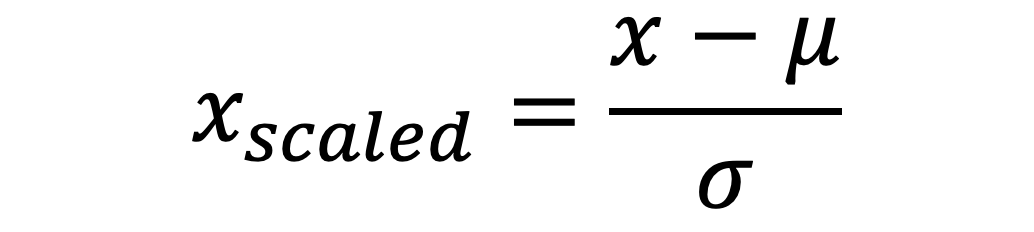

In [ ]:
# 여기에 답안코드를 작성하세요.
mu = X_train.mean()
sigma = X_train.std()

x_train = (X_train - mu) / sigma
x_valid = (X_valid - mu) / sigma

print("X_train 표준화 스케일링 전:\n", X_train)
print()
print("X_train 표준화 스케일링 후:\n", x_train)

### 13. 주택 가격을 예측하는 머신러닝 모델을 만들려고 합니다.
---
다음 가이드에 따라 두 개의 머신러닝 모델을 구현하세요.
 - sklearn의 GradientBoostingRegressor 모델을 gbr 변수에 저장하세요.
     - 트리의 최대 깊이 : 7로 설정
     - 트리의 개수: 50으로 설정
     - learning_rate: 0.05로 설정
     - random_state : 42로 설정
- xgboost의 XGBRegressor 모델을 xgbr 변수에 저장하세요
    - 트리의 최대 깊이: 7로 설정
    - 트리의 개수: 50으로 설정
    - learning_rate: 0.05로 설정
    - random_state: 42로 설정
- 위의 2개의 모델을 학습해 주세요. 학습 시 최종 전처리된 훈련 데이터셋을 활용해 주세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

gbr = GradientBoostingRegressor(max_depth=7, n_estimators=50, learning_rate=0.05, random_state=42)
xgbr = XGBRegressor(max_depth=7, n_estimators=50, learning_rate=0.05, random_state=42)

gbr.fit(x_train, y_train)
xgbr.fit(x_train, y_train)

### 14. 13번에서 학습한 모델의 성능을 평가하려고 합니다.
---
앞에서 학습한 두 가지 모델의 성능을 비교해 봅시다.
- 성능 평가는 최종 전처리된 검증 데이터셋을 활용하세요.
- 각 모델을 활용해 검증데이터에 대해 y값을 예측(predict)하고 각각 y_pred_gbr, y_pred_xgbr 변수에 저장하세요.
- 각 모델 예측값에 대해 MAE를 계산하고 성능을 비교하세요.
- 두 모델 중 MAE 기준으로 성능이 더 좋은 모델의 MAE 값을 소수점 둘째 자리까지 반올림하여 '답안14' 변수에 저장하세요. (예: 답안14=0.15)
---

In [ ]:
# 여기에 답안코드를 작성하세요.
from sklearn.metrics import mean_absolute_error

y_pred_gbr = gbr.predict(x_valid)
y_pred_xgbr = xgbr.predict(x_valid)

print("GradientBoostingRegressor 결과")
print(mean_absolute_error(y_valid, y_pred_gbr))

print("XGBRegressor 결과")
print(mean_absolute_error(y_valid, y_pred_xgbr))

답안14 = 21.95

### 15. 14번에서 가장 성능이 좋았던 모델을 가지고 컬럼의 중요도를 확인해보려고 합니다.
---
모델의 feature_importances_를 계산하고 중요도로 내림차순으로 정렬하여 출력하세요.

- 컬럼이름은 전처리가 완료된 학습데이터의 컬럼명을 사용하세요.
- 가장 높은 중요도를 가진 컬럼의 이름을 "답안15"변수에 작성하세요.
---

In [ ]:
# 여기에 답안코드를 작성하세요.
feature_importance = xgbr.feature_importances_
feature_name = X.columns

df_importance = pd.DataFrame({'importance': feature_importance,
                              'features': feature_name})

df_importance.sort_values(by='importance', ascending=False, inplace=True)
display(df_importance)

답안15 = 'SQUARE_FT'

다음 문항을 풀기 전에 아래의 코드를 실행하세요.

In [ ]:
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)
# print(tf.config.list_physical_devices('CPU'))

### 16. 주택 가격을 예측하는 딥러닝 모델을 만들려고 합니다.
---
아래 가이드에 따라 모델링하고 학습을 진행하세요.
- Tensorflow framework를 사용하여 딥러닝 모델을 만드세요.
- 아래의 설계된 모델을 구현하세요.
- 손실함수는 'mse'를 사용하고, 손실함수를 최적화하기 위한 알고리즘은 'adam'을 사용하세요.
- 각 에포크마다 검증데이터셋을 'mae'로 평가하세요.
- 하이퍼파라미터
    - epochs: 100
    - batch_size: 512
- 각 에포크마다 loss와 metrics를 평가하기 위한 데이터로 전처리가 완료된 검증 데이터셋을 사용하세요.
- EarlyStopping을 사용하여 val_loss를 보고 8회의 대기 후 성능이 향상되지 않으면 종료하며, 가장 낮은 검증 손실을 낸 모델 파라미터로 복구하세요.
- ModelCheckpoint를 활용하여 동일 폴더에 'best_dl_model.h5'라는 이름의 가장 좋은 성능의 모델만 저장하세요.
- 학습정보는 history 변수에 저장해 주세요.
---

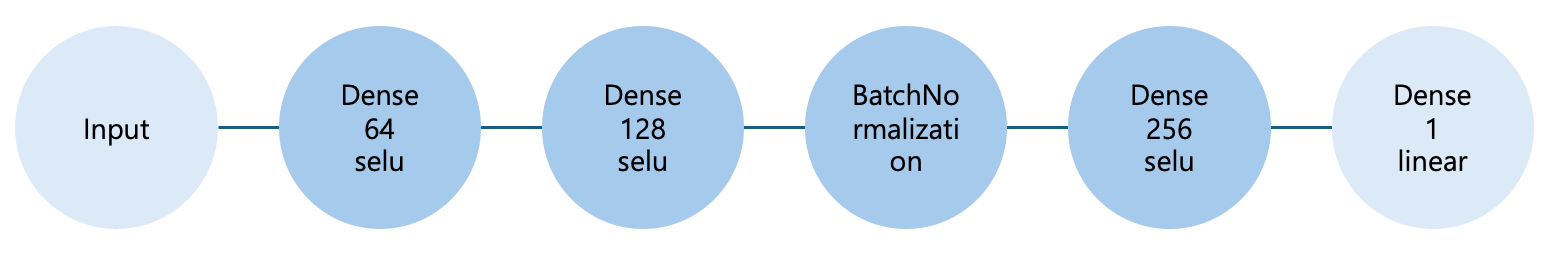

In [ ]:
# 여기에 답안코드를 작성하세요.
model = Sequential([
    Dense(64, activation='selu', input_shape=(X.shape[1],)),
    Dense(128, activation='selu'),
    BatchNormalization(),
    Dense(256, activation='selu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
mc = ModelCheckpoint('best_dl_model.h5', save_best_only=True)

history = model.fit(x_train, y_train, epochs=100, batch_size=512, validation_data=(x_valid, y_valid), callbacks=[es, mc])

### 17. 16번에서 저장한 딥러닝 모델을 불러와서 주어진 데이터로 시뮬레이션을 하려 합니다.
---
다음 가이드를 따라 시뮬레이션을 진행하세요.
- tensorflow.keras.models의 load_model을 사용하여 'best_dl_model.h5' 모델을 best_dl 변수로 불러옵니다.
- 주어진 시뮬레이션 데이터에 대해 예측결과를 구하고 주택 가격을 정수 형태로 반올림하여 '답안17' 변수에 저장하세요.
- 예) 답안17=100000
---

In [ ]:
simul = np.array([1.27429129, 0.76915829, -0.02726393, -0.00985667, 1.16264519, 0.04765242, -0.46812722, -1.4646994, 0.46812722, 0.26605664]).reshape(1, -1)

In [ ]:
# 여기에 답안코드를 작성하세요.
best_dl = load_model('best_dl_model.h5')
print(np.round(best_dl.predict(simul)))

답안17 = 47

모든 문제를 다 푸셨습니다. 고생하셨습니다.